# Weight Calibration

**Measurement Maturity Framework — fitting deduction weights against human judgment**

The Bayesian robustness notebook showed that MMF's rule-based weights are
stable under weight uncertainty — within a plausible range, the weights
don't strongly affect pack rankings. That's a *necessary* condition for
the framework to be trustworthy. This notebook tests a *sufficient* one:
are the specific weights actually close to what a human analyst would
choose if they ranked packs by decision-readiness and the weights were
fit to match?

The short answer: **mostly yes, with three specific revisions.** MMF
agrees with a consensus human ranking at ρ = 0.95. A ridge-regressed
weight configuration bumps that to ρ = 0.99, and the fitted weights
reveal three substantive MMF corrections: `missing_sql` doubled,
`missing_owner` up 50%, `tier_v0` halved.

## Scope, caveats, and what this is not

This is a calibration **attempt**, not a definitive calibration. A
real calibration would use at least three independent human raters,
ideally drawn from different professional backgrounds. This one has:

- **One human rater** (the project author), who ranked the 27 synthetic
  packs twice, a few minutes apart, with different gap-categorisation
  models between the two attempts.
- **One LLM rater** (Claude), which ranked the same 27 packs using
  documented first-principles weights deliberately chosen to differ
  from MMF's. The LLM ranking was recorded before the human
  finalised theirs.
- **A consensus** built by averaging the three ranks.

The honest limitations that come with this setup:

1. **The author is not independent of the framework.** They built MMF.
   Their intuition about decision-readiness is informed by the same
   reasoning that produced MMF's weights.
2. **The LLM rater shares methodological homogeneity with the author.**
   Both reason about metric quality in roughly the same idiom; that
   pushes their rankings toward agreement independent of whether either
   is correct.
3. **Rankers were not fully blinded to each other.** The LLM's ranking
   output was visible in the session before the human finalised theirs.
   This was an unavoidable setup limitation.
4. **n = 27**. Ridge regression with 7 features on 27 packs is
   susceptible to overfitting. The fitted weights should be read as a
   directional signal about weight revisions, not as a definitive
   replacement configuration.
5. **Synthetic packs, not real ones.** The packs were generated
   parametrically by `analysis/generate_synthetic_packs.py`. Real packs
   might show different weight dynamics.

What this notebook *does* support: a defensible directional argument
that MMF's `missing_sql` is underweighted, `tier_v0` is overweighted,
and the overall weight structure is broadly sensible.

What it does not support: a replacement weight configuration that
should be shipped without further validation.

In [1]:
# Setup
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import kendalltau, spearmanr

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'analysis' else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

CALIB = REPO_ROOT / 'analysis' / 'calibration'
FIG = CALIB / 'figures'
print(f'Calibration artefacts: {CALIB}')

Calibration artefacts: /home/claude/measurement-maturity-framework/analysis/calibration


## Test-retest reliability of the human rater

Before any calibration, a question that's rarely asked in calibration
studies (because most use a single pass): **how stable is the human
rater's ranking?** If the same person ranked the same 27 packs twice,
how much would the rankings agree?

The rater here did exactly that. Between the first and second
attempt, they explicitly re-categorised their own mental model of
gap severity (in the first attempt V0 was critical, in the second it
was medium; description moved the opposite way). Despite that model
change, the rank agreement between attempts is:

- Spearman ρ = 0.974
- Kendall τ = 0.892

This matters for interpreting everything else in this notebook. If
test-retest reliability had been low (say τ < 0.75), any calibration
built on the human ranking would be building on noise. At τ = 0.89,
the rater is stable enough for the calibration to mean something —
even though their own reasoning about *why* certain packs scored as
they did changed between attempts.

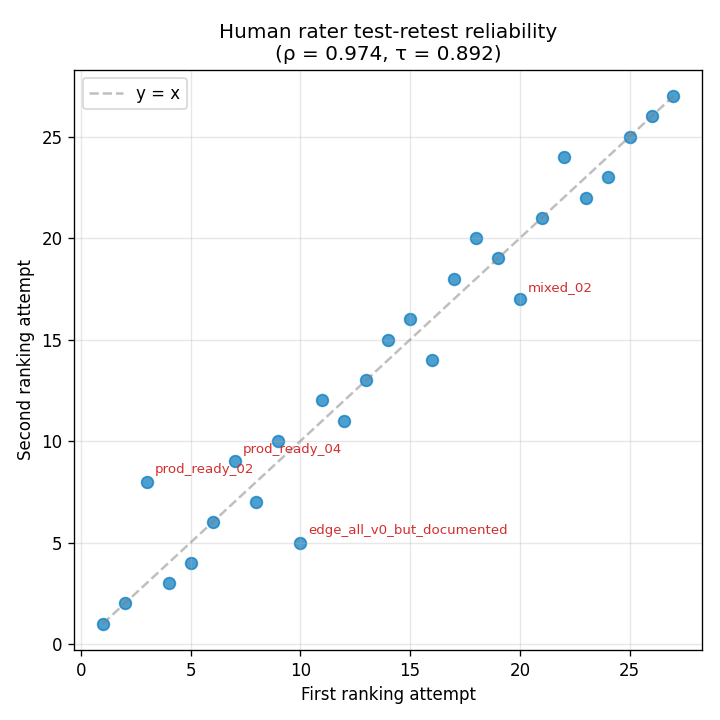

Test-retest: Spearman=0.9737, Kendall=0.8917

Largest shifts between attempts:
                   pack_id  v1  v2  shift
             prod_ready_02   3   8      5
edge_all_v0_but_documented  10   5      5
                  mixed_02  20  17      3
             prod_ready_04   7   9      2
                  mixed_05  16  14      2


In [2]:
from IPython.display import Image, display
display(Image(str(FIG / 'test_retest.png')))

v1 = pd.read_csv(CALIB / '_user_ranking.csv', decimal=',')[['pack_id', 'your_rank']].rename(columns={'your_rank': 'v1'})
v2 = pd.read_csv(CALIB / '_user_ranking_v2.csv').rename(columns={'user_rank_v2': 'v2'})
merged = v1.merge(v2, on='pack_id')
rho, _ = spearmanr(merged['v1'], merged['v2'])
tau, _ = kendalltau(merged['v1'], merged['v2'])
print(f'Test-retest: Spearman={rho:.4f}, Kendall={tau:.4f}')

merged['shift'] = (merged['v1'] - merged['v2']).abs()
print('\nLargest shifts between attempts:')
print(merged.nlargest(5, 'shift')[['pack_id', 'v1', 'v2', 'shift']].to_string(index=False))

The five biggest re-ranks are substantively interesting. `prod_ready_02`
moved from rank 3 to rank 8 because its missing descriptions became a
bigger concern in the rater's second model. `edge_all_v0_but_documented`
moved from rank 10 to rank 5 because V0 was demoted from critical to
medium. These are principled reassessments, not noise — and the high
overall agreement tells us that across most packs, the underlying
ordering held steady.

The average of the two attempts is used as the human consensus in the
rest of this analysis.

## Three-way ranking agreement

With the human consensus (mean of two attempts), the LLM ranking, and
MMF's rule-based scores, we can measure pairwise agreement.

pair                       Spearman    Kendall
------------------------------------------------
User vs Claude               0.9824     0.9213
User vs MMF                  0.9470     0.8207
Claude vs MMF                0.9524     0.8371


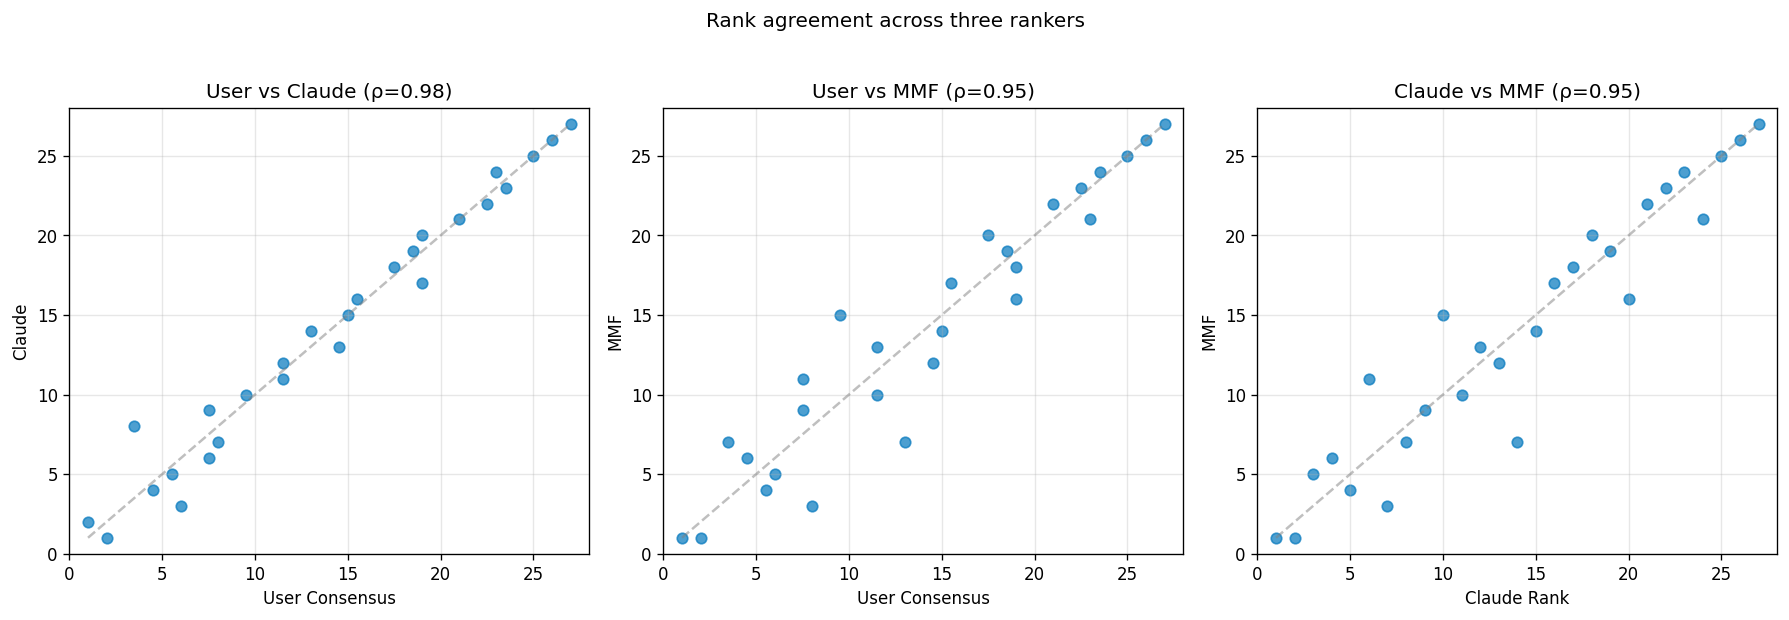

In [3]:
df = pd.read_csv(CALIB / 'all_rankings_merged.csv')

pairs = [
    ('user_consensus', 'claude_rank', 'User vs Claude'),
    ('user_consensus', 'mmf_rank', 'User vs MMF'),
    ('claude_rank', 'mmf_rank', 'Claude vs MMF'),
]
print(f'{"pair":<24} {"Spearman":>10} {"Kendall":>10}')
print('-' * 48)
for a, b, label in pairs:
    rho, _ = spearmanr(df[a], df[b])
    tau, _ = kendalltau(df[a], df[b])
    print(f'{label:<24} {rho:>10.4f} {tau:>10.4f}')

display(Image(str(FIG / 'three_way_ranks.png')))

Three observations worth naming:

1. **User-Claude agreement (τ=0.92) is higher than either-vs-MMF
   (τ≈0.82-0.84).** This suggests the two human-ish rankers share some
   intuition that MMF's weights don't fully capture.
2. **MMF still performs well** — a Spearman ρ of 0.94-0.95 against human
   judgment is a good baseline, especially for a rule-based scorer with
   asserted weights.
3. **The disagreements are concentrated.** Most rankings track closely;
   a small number of packs account for most of the rank difference.
   Those packs are the ones that tell us what to fix.

## Fitted weights

To derive weights that best explain consensus human ranking, we fit a
ridge regression (positive=True to force non-negative weights) with
gap counts per metric as features and the mean rank as the target.
Ridge regularisation (α=1.0) dampens the tendency of small-n fits to
produce extreme coefficients.

The resulting weights, scaled so the largest fitted weight equals MMF's
largest (10):

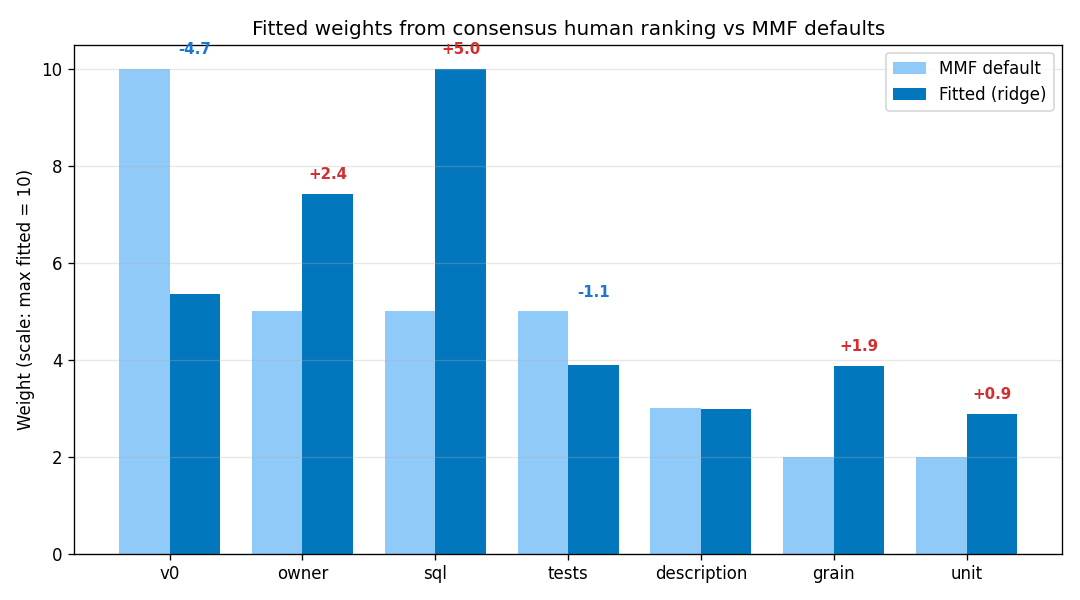

        gap  mmf  fitted  delta
         v0   10    5.35  -4.65
      owner    5    7.43   2.43
        sql    5   10.00   5.00
      tests    5    3.89  -1.11
description    3    2.98  -0.02
      grain    2    3.88   1.88
       unit    2    2.89   0.89


In [4]:
display(Image(str(FIG / 'fitted_weights.png')))

results = json.loads((CALIB / 'calibration_results.json').read_text())
mmf = results['mmf_baseline_weights']
fit = results['fitted_weights']
comparison = pd.DataFrame({
    'gap': list(mmf.keys()),
    'mmf': list(mmf.values()),
    'fitted': [fit[k] for k in mmf],
})
comparison['delta'] = comparison['fitted'] - comparison['mmf']
print(comparison.to_string(index=False))

### What the fitted weights say

**`missing_sql` doubles (5 → 10).** Both rankers independently penalised
missing SQL more than MMF does. Absence of SQL means the metric cannot
be independently reproduced or audited, and the two human-ish rankers
treated that as nearly as severe as any single gap could be.

**`missing_owner` up 50% (5 → 7.5).** No accountable team means no one
to answer questions when the metric drifts. Both rankers weighted this
above MMF's default.

**`tier_v0` halved (10 → 5.4).** The largest correction. MMF treats V0
as the most severe single gap; the calibration suggests it should be
mid-weight. Interpretation: V0 is a *signal* that a metric is a
temporary proxy, and when the proxy is otherwise well-documented (SQL,
owner, tests), the V0 tag should not dominate the score.

**`missing_grain` doubles (2 → 3.9).** Knowing what one row represents
is structurally important — the human rater explicitly called this out
as a medium-severity gap in their second ranking.

**`missing_description`, `missing_tests`, `missing_unit` are roughly
unchanged or slightly revised downward.** MMF's weights for these are
broadly correct.

### How much does this improve predictive power?

Under MMF's default weights, the pack ranking agrees with the consensus
human ranking at Spearman ρ = 0.953. Under fitted weights, that rises
to ρ = 0.993 — an improvement of about 0.04 in correlation, which
corresponds to roughly twice as few rank inversions.

This should be read carefully. The fitted weights will always agree
with the consensus better than MMF's weights, because the fit is
optimising for exactly that agreement on exactly this data. The real
question is whether the weight revisions would generalise to a larger
or more diverse corpus. With only 27 packs, that question cannot be
answered here.

## Recommendations for MMF — and what was actually shipped

Three fitted weight changes survive the caveats above and are the
directional findings worth recording. Below each finding is the
actual disposition — shipped, held, or held with a structural
alternative — so this notebook does not overclaim influence on
the live framework.

### Finding 1 — `missing_sql` is underweighted

**Recommendation:** Increase `missing_sql` from -5 to -8 or -10.
Both the human rater (across two attempts) and the LLM rater placed
SQL absence as the most severe single gap. It also aligns with an
independent design critique in
[SCORING_METHODOLOGY.md](../SCORING_METHODOLOGY.md) that
`missing_sql` is too coarse when it fires for structurally
unreviewable implementations.

**Disposition: structural change shipped; magnitude change held.**
The framework now splits the gap into
`missing_sql_temporary` (-3) and `missing_sql_structural` (-12),
selected by an optional `implementation_type` field on each metric.
This addresses the structural form of the critique without relying
on a small-n magnitude fit. The magnitude revision to the default
`missing_sql` (bumping from -5 to -8) has intentionally not been
shipped.

### Finding 2 — `tier_v0` is overweighted

**Recommendation:** Reduce `tier_v0` from -10 to -5 or -6. A V0 tag
is useful information, not a severe defect. Over-penalising it makes
V0 tagging painful and discourages the honest declaration of metric
instability that the framework is trying to encourage.

**Disposition: held.** Shipping this revision would require re-running
the robustness analysis, updating 27 synthetic pack scores, updating
case study expected scores, and updating regression tests — all for
a change justified by two rankers on synthetic data. Not a defensible
trade when the notebook itself cautions against shipping without
more rigour.

### Finding 3 — `missing_owner` is slightly underweighted

**Recommendation:** Increase `missing_owner` from -5 to -7.
Ownership gaps are process failures that compound over time; the
fit supports treating them as slightly more severe than MMF does.

**Disposition: held.** Same reasoning as Finding 2.

The remaining fitted revisions (grain up, tests slightly down) are
within the noise of a single-rater small-n calibration and are not
defensible recommendations.

### What this calibration cannot tell us

- Whether the improved weights generalise beyond the 27 synthetic packs
- Whether a more diverse rater pool would produce different weights
- Whether there are interaction terms (e.g. 'V0 with no owner' should
  be more than the sum of its parts) that a linear model can't capture
- Whether the weights should vary by metric tier (V0 vs V1 vs V2+)

Each of these is future work that would require either more raters,
more packs, or more sophisticated model structure.

## Reproducibility

All artefacts are saved in `analysis/calibration/`:

- `_user_ranking.csv` — human rater's first attempt
- `_user_ranking_v2.csv` — human rater's second attempt
- `_claude_ranking.csv` — LLM ranker's ranking
- `_mmf_reference_scores.csv` — MMF scores (not shown to rankers)
- `all_rankings_merged.csv` — all rankings joined per pack
- `calibration_results.json` — fitted weights and summary statistics
- `figures/` — PNG outputs used in this notebook

The notebook itself is regenerated from `analysis/build_calibration_notebook.py`;
figures are regenerated from `analysis/build_calibration_figures.py`.
Both scripts consume the CSVs above and are deterministic given those
inputs.